Лабораторна робота №2 “Пошук асоціативних правил”
Метою даної лабораторної роботи є ознайомлення з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.



In [159]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules


На цьому етапі було залучено всі основні інструменти, які необхідні для виконання лабораторної роботи. Це дозволяє перейти до завантаження, обробки та подальшого аналізу даних. Якщо детальніше, то: pandas - для роботи з таблицями, numpy - для допоміжних математичних операцій, matplotlib - для побудови графіків, apriori - для пошуку частих наборів та association_rules - для побудови асоціативних правил.

In [160]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

Зчитуємо два основні набори даних: таблицю оцінок користувачів та таблицю з назвами фільмів. Це наша інформаційна база для подальшого аналізу, оскільки одна таблиця містить інформацію про оцінки, а інша — про відповідні назви фільмів.

In [161]:
print("Перші рядки таблиці ratings:")
display(ratings.head())
print("Перші рядки таблиці movies:")
display(movies.head())

Перші рядки таблиці ratings:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Перші рядки таблиці movies:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Робимо перевірку, щоб зрозуміти чи правильно файли зчитались, і дивимось на структуру таблиць.


In [162]:
print("Розмір таблиці ratings:", ratings.shape)
print("Розмір таблиці movies:", movies.shape)
print("Кількість унікальних користувачів:", ratings["userId"].nunique())
print("Кількість унікальних фільмів у ratings:", ratings["movieId"].nunique())
print("Кількість унікальних фільмів у movies:", movies["movieId"].nunique())

Розмір таблиці ratings: (100836, 4)
Розмір таблиці movies: (9742, 3)
Кількість унікальних користувачів: 610
Кількість унікальних фільмів у ratings: 9724
Кількість унікальних фільмів у movies: 9742


Дану операцію робимо, щоб зрозуміти обсяг даних, які ми обробляємо. Також це нам дасть змогу виконувати певні порівняння при подальшому накладанні умов та відкиданні частини даних.

In [163]:
data = ratings.merge(movies, on="movieId")
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


За варіантом завдання ми об’єднуємо дві таблиці за полем movieId, щоб кожна оцінка користувача була пов’язана з назвою відповідного фільму.

In [164]:
liked_movies = data[data["rating"] >= 4.0]
liked_movies.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Наступний пункт завдання - це відкинути фільми з оцінкою нижче 4.0. Після фільтрації у нас в таблиці залишаються лише позитивно оцінені фільми. Таким чином, подальший аналіз буде виконуватися не для всіх переглядів, а для звуженої вибірки.

In [165]:
print("Розмір об'єднаної таблиці:", data.shape)
print("Розмір таблиці після фільтрації rating >= 4.0:", liked_movies.shape)
print("Кількість користувачів після фільтрації:", liked_movies["userId"].nunique())
print("Кількість фільмів після фільтрації:", liked_movies["title"].nunique())

Розмір об'єднаної таблиці: (100836, 6)
Розмір таблиці після фільтрації rating >= 4.0: (48580, 6)
Кількість користувачів після фільтрації: 609
Кількість фільмів після фільтрації: 6297


Виводимо інфу про фільтровану таблицю. Видно, наскільки скоротився набір даних після того, як ми залишили тільки позитивні оцінки.

In [166]:
basket = liked_movies.groupby(['userId', 'title'])['rating'] \
                     .count().unstack().fillna(0)
basket.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


У результаті сформовано транзакційну матрицю взаємодії користувачів із фільмами, де кожен рядок відповідає окремому користувачу, а кожен стовпець - певному фільму. Значення більше нуля означає, що користувач поставив позитивну оцінку цьому фільму. Далі виконаємо перетворення значень в бінарний формат True та False.

In [167]:

basket_binary = (basket > 0).astype(bool)
basket_binary.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Матриця була приведена до бінарного вигляду, де значення True означає, що користувач вподобав фільм, а False - що ні. Такий формат є стандартним для задач пошуку асоціативних правил (в нашому випадку це алгоритм Apriori).

In [168]:
print("Розмір транзакційної матриці:", basket_binary.shape)
basket_binary.iloc[:5, :5]

Розмір транзакційної матриці: (609, 6297)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)"
userId,,,,,
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False


Отримані розміри матриці показують, скільки транзакцій (користувачів) та елементів (фільмів) буде використано для подальшого аналізу. Також ми провели візуальний перегляд частини матриці, щоб переконатись в правильності даних.

In [169]:
frequent_itemsets_005 = apriori(basket_binary, min_support=0.05, use_colnames=True)
frequent_itemsets_005['length'] = frequent_itemsets_005['itemsets'].apply(lambda x: len(x))
print("Найпопулярніші фільми та їх комбінації при min_support = 0.05:")
frequent_itemsets_005.sort_values(by='support', ascending=False).head(10)

Найпопулярніші фільми та їх комбінації при min_support = 0.05:


,support,itemsets,length
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
119,0.408867,frozenset({Forrest Gump (1994)}),1
244,0.400657,frozenset({Pulp Fiction (1994)}),1
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
206,0.364532,"frozenset({Matrix, The (1999)})",1
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...,1
115,0.293924,frozenset({Fight Club (1999)}),1
260,0.287356,frozenset({Schindler's List (1993)}),1
2228,0.275862,"frozenset({Shawshank Redemption, The (1994), F...",2
300,0.275862,frozenset({Star Wars: Episode V - The Empire S...,1


In [170]:
print("Кількість частих наборів при min_support = 0.05:", frequent_itemsets_005.shape[0])

Кількість частих наборів при min_support = 0.05: 33189


При min_support = 0.05 алгоритм знаходить найбільшу кількість частих наборів, оскільки поріг підтримки є відносно невисоким. Це дозволяє нам побачити не лише наймасовіші вподобання користувачів, а й менш поширені серед користувачів, але все ще достатньо часті комбінації фільмів.

In [171]:
frequent_itemsets_01 = apriori(basket_binary, min_support=0.1, use_colnames=True)
frequent_itemsets_01['length'] = frequent_itemsets_01['itemsets'].apply(lambda x: len(x))
print("Найпопулярніші фільми та їх комбінації при min_support = 0.1:")
frequent_itemsets_01.sort_values(by='support', ascending=False).head(10)


Найпопулярніші фільми та їх комбінації при min_support = 0.1:


,support,itemsets,length
93,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
40,0.408867,frozenset({Forrest Gump (1994)}),1
83,0.400657,frozenset({Pulp Fiction (1994)}),1
96,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
68,0.364532,"frozenset({Matrix, The (1999)})",1
103,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...,1
38,0.293924,frozenset({Fight Club (1999)}),1
90,0.287356,frozenset({Schindler's List (1993)}),1
279,0.275862,"frozenset({Shawshank Redemption, The (1994), F...",2
104,0.275862,frozenset({Star Wars: Episode V - The Empire S...,1


In [172]:
print("Кількість частих наборів при min_support = 0.1:", frequent_itemsets_01.shape[0])

Кількість частих наборів при min_support = 0.1: 863


Порівняно з попереднім випадком, кількість частих наборів зменшується, оскільки поріг відбору стає жорсткішим. Це означає, що частина менш популярних комбінацій уже не задовольняє умову підтримки.

In [173]:
frequent_itemsets_03 = apriori(basket_binary, min_support=0.3, use_colnames=True)
frequent_itemsets_03['length'] = frequent_itemsets_03['itemsets'].apply(lambda x: len(x))
print("Найпопулярніші фільми та їх комбінації при min_support = 0.3:")
frequent_itemsets_03.sort_values(by='support', ascending=False).head(10)


Найпопулярніші фільми та їх комбінації при min_support = 0.3:


,support,itemsets,length
3,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
0,0.408867,frozenset({Forrest Gump (1994)}),1
2,0.400657,frozenset({Pulp Fiction (1994)}),1
4,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
1,0.364532,"frozenset({Matrix, The (1999)})",1
5,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...,1


In [174]:
print("Кількість частих наборів при min_support = 0.3:", frequent_itemsets_03.shape[0])

Кількість частих наборів при min_support = 0.3: 6


Для високого значення min_support кількість знайдених наборів є найменшою. Це підтверджує теорію, що зі збільшенням порогу підтримки алгоритм поступово відсікає менш поширені комбінації та залишає лише найбільш типові.

In [175]:
print("Порівняння кількості частих наборів:")
print("min_support = 0.05 ->", frequent_itemsets_005.shape[0])
print("min_support = 0.10 ->", frequent_itemsets_01.shape[0])
print("min_support = 0.30 ->", frequent_itemsets_03.shape[0])

Порівняння кількості частих наборів:
min_support = 0.05 -> 33189
min_support = 0.10 -> 863
min_support = 0.30 -> 6


Отже, параметр min_support - це мінімальна частка користувачів, у яких має зустрічатися набір, щоб він вважався частим.
Експериментально ми побачили, що при збільшенні min_support кількість знайдених наборів зменшується. А при малому min_support ми отримуємо більше результатів, але серед них більше шуму, що може бути на заваді об'єктивного аналізу. Було проаналізовано часті набори фільмів при різних значеннях параметра min_support. Отримані результати показують, як зміна порогу підтримки впливає на обсяг і характер знайдених комбінацій. Якщо говорити про конкретику, то найбільший support мають класичні популярні фільми, що означає їх високу поширеність серед користувачів. Також при значенні min_support = 0.05 алгоритм дозволяє виявити не лише найбільш популярні окремі фільми, але й часті комбінації, які можуть бути використані для побудови рекомендаційних систем. Можна побачити, що The Shawshank Redemption (1994) разом із Forrest Gump (1994). Можна зробити припущення, що ці фільми мають спільну аудиторію.

In [176]:
rules = association_rules(frequent_itemsets_005, metric="lift", min_threshold=1.2)
rules.head()
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

print("Топ-10 асоціативних правил:")
top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

Топ-10 асоціативних правил:


,antecedents,consequents,support,confidence,lift
463536,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.780488,13.203252
463541,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.888889,13.203252
463556,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.780488,12.846407
463557,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.780488,12.846407
463521,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.864865,12.846407
463520,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.864865,12.846407
463525,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.969697,12.837945
463552,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.695652,12.837945
463542,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode V - The Empire S...,0.052545,0.842105,12.821053
463535,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode VI - Return of t...,0.052545,0.800000,12.821053


У результаті побудови асоціативних правил було виявлено сильні залежності між окремими фільмами.
Support - показує, як часто набір зустрічається серед усіх користувачів.
Confidence - наскільки часто B є, якщо є A
Lift - показує, чи це реальна залежність, чи випадковість
Найбільш показовими є правила, пов’язані з фільмами серії Star Wars, зокрема між Episode V - The Empire Strikes Back та Episode VI - Return of the Jedi. Ці фільми разом зустрічаються приблизно у 5% користувачів також існує висока ймовірність того, що користувач, який переглянув один фільм, переглянув і інший. Також значення lift є високим, та свідчить про НЕ випадковість.

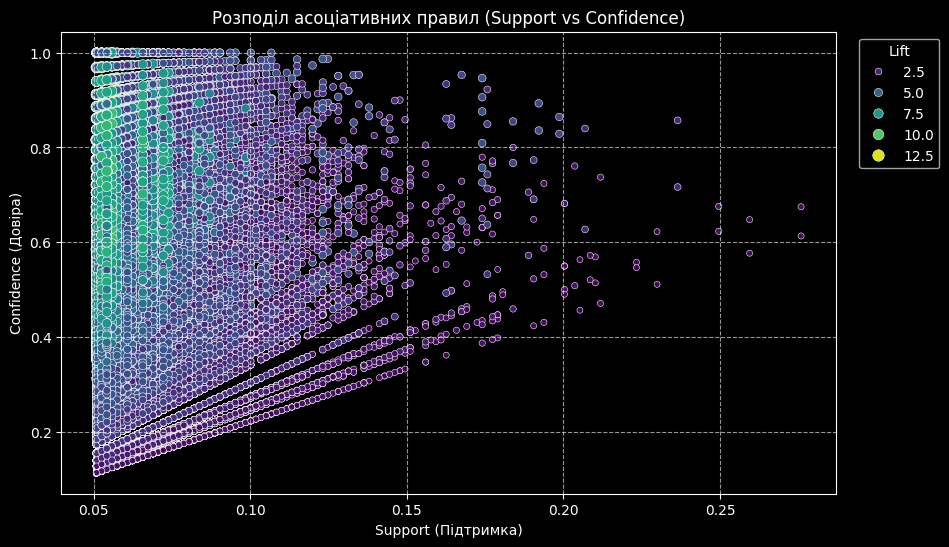

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="support",
    y="confidence",
    size="lift",
    hue="lift",
    data=rules,
    palette="viridis"
)
plt.title("Розподіл асоціативних правил (Support vs Confidence)")
plt.xlabel("Support (Підтримка)")
plt.ylabel("Confidence (Довіра)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Lift')
plt.show()

Було побудовано графік розсіювання, який відображає розподіл асоціативних правил за трьома основними метриками: support, confidence та lift. Кожна точка на графіку відповідає окремому правилу та дозволяє оцінити його якість і значущість.

Аналіз показав, що більшість правил зосереджені в області низьких значень support, що є характерним для нашої умови задачі, де комбінації фільмів зустрічаються значно рідше, ніж окремі популярні фільми. При цьому значення confidence для значної частини правил є високими (0.6–1.0), що свідчить про високу ймовірність того, що перегляд одного фільму пов’язаний із переглядом іншого.

Колір та розмір точок відображають значення lift, яке для деяких правил досягає високих значень. Це вказує на наявність сильних, невипадкових зв’язків між фільмами, навіть якщо такі комбінації не є масовими. Найбільш яскраві точки зосереджені в області низького support, що означає виявлення специфічних вподобань окремих груп користувачів.


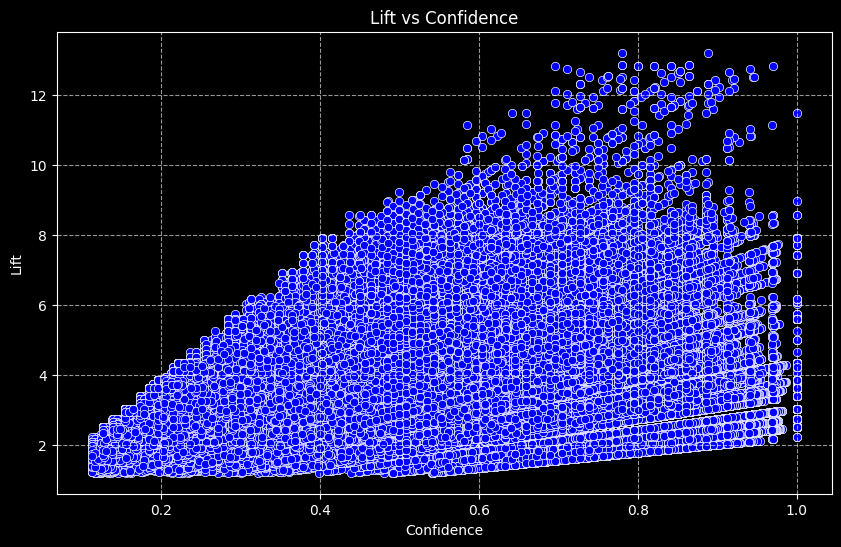

In [178]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="confidence",
    y="lift",
    data=rules,
    color="blue"
)
plt.title("Lift vs Confidence")
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Також створено графік зв'язку між lift та confidence. Видно, що зі збільшенням confidence зростає і lift, тобто більш надійні правила часто мають сильніший зв’язок між фільмами. Найцінніші(для правильного аналізу) правила знаходяться у верхній правій частині графіка - вони одночасно мають високий confidence і високий lift, що свідчить про сильні та невипадкові залежності.

Висновок


У ході лабораторної роботи було досліджено методи пошуку асоціативних правил на основі набору даних MovieLens. Дані було підготовлено та перетворено у транзакційний формат, що дозволило представити вподобання користувачів у вигляді наборів фільмів і застосувати алгоритм Apriori. Було встановлено, що значення параметра min_support суттєво впливає на результати. Побудова асоціативних правил дозволила виявити закономірності у вподобаннях користувачів. Було знайдено певні зв'язки між фільмами, а також встановлено чи це випадковість, чи закономірність. Аналіз графіків показав, що більшість правил має невисокий support, але високий confidence, а найцінніші правила характеризуються високими значеннями lift. Це означає, що навіть менш поширені комбінації можуть містити важливу інформацію про поведінку користувачів. Отже, проведена робота в рамках лабораторної роботи дала можливість виявити як і явні закономірності, так і приховані.